In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(statistical, None)--
	Fractional uncertainty: 0.40%
--Systematic(stats, Stat.)--
	Fractional uncertainty: 0.40%
--Systematic(MC_total, All Systematics (No G4))--
	Fractional uncertainty: 0.40%

Processing systematics for sample: mc_nonmatched

Processing systematics for sample: onbeam

Processing systematics for sample: offbeam
Setting weight for mc to 3.03e-02
Setting weight for mc_nonmatched to 3.03e-02
Setting weight for onbeam to 1.00e+00
Setting weight for offbeam to 9.53e-02
Fractional - Min: 1.27%, Max: 2.57%
Fractional - Min: 2.60%, Max: 4.76%
Fractional - Min: 1.44%, Max: 3.42%


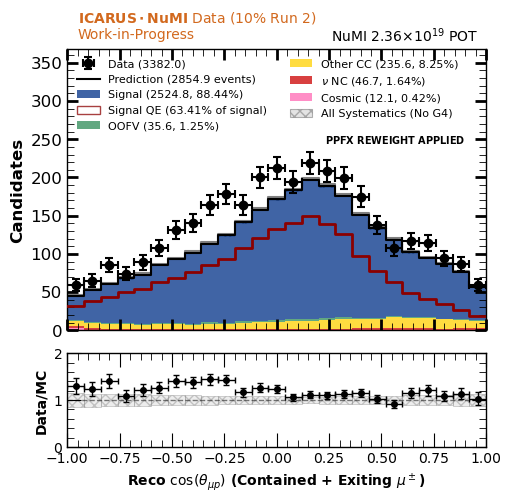

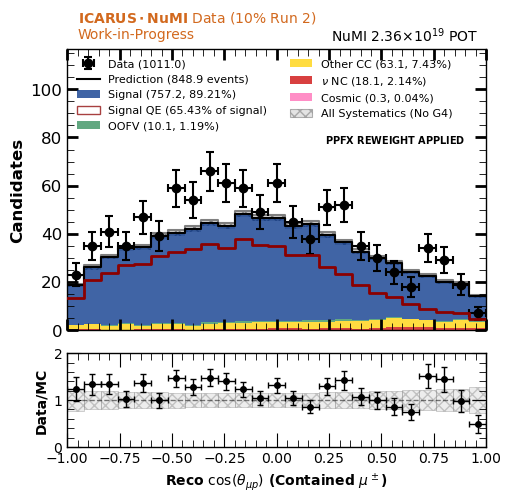

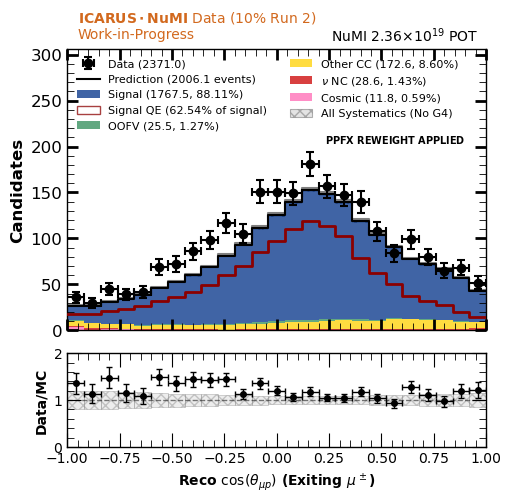

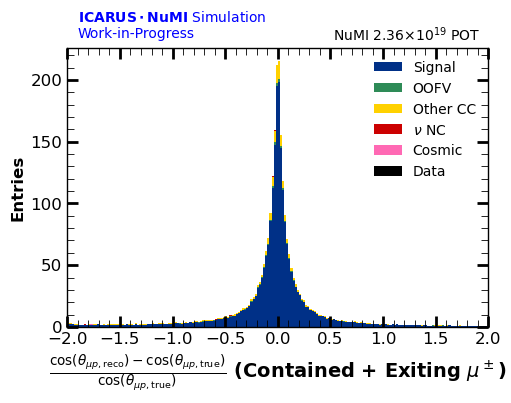

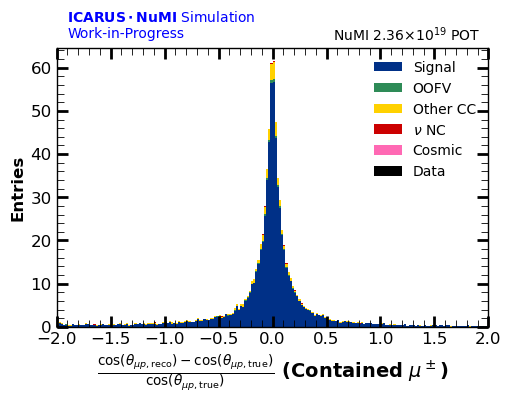

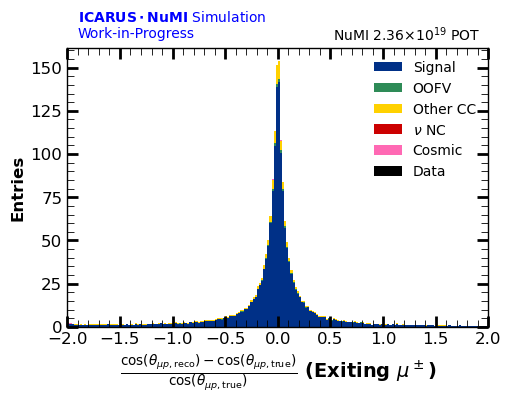

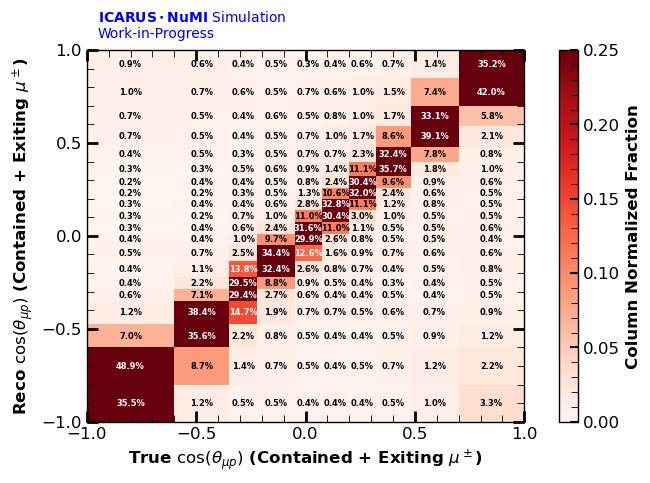

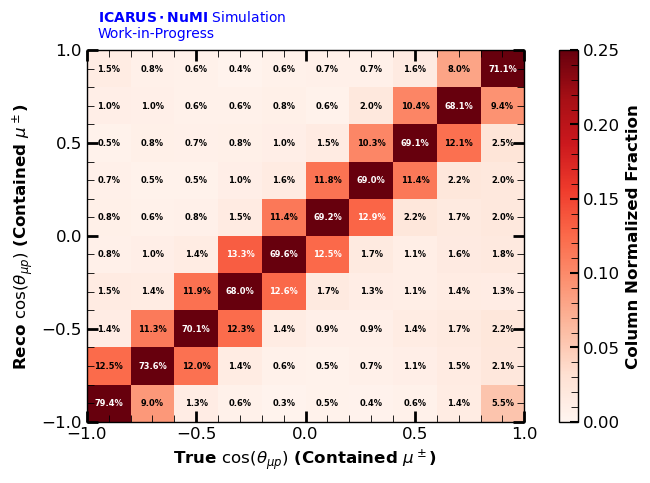

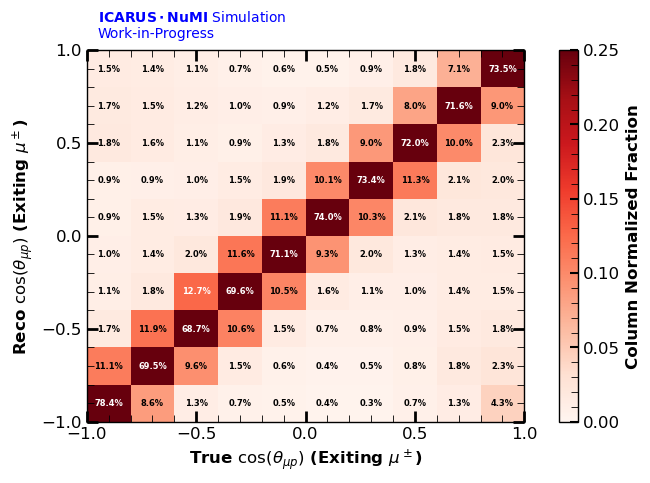

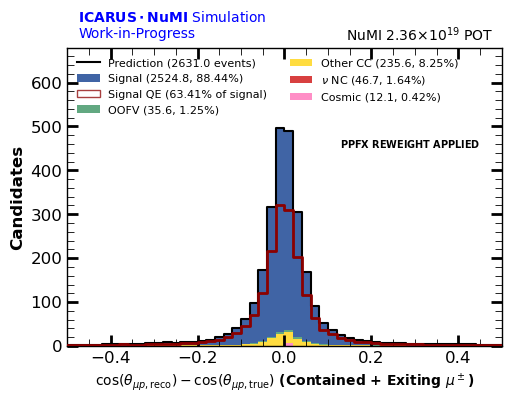

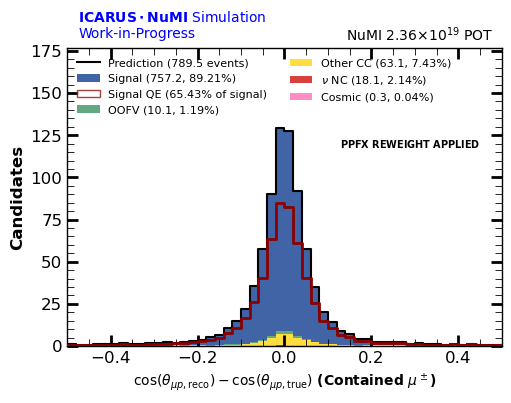

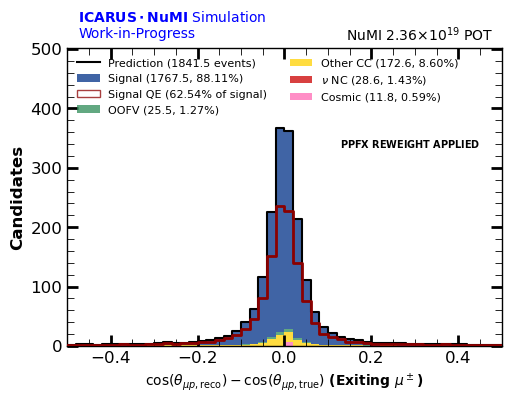

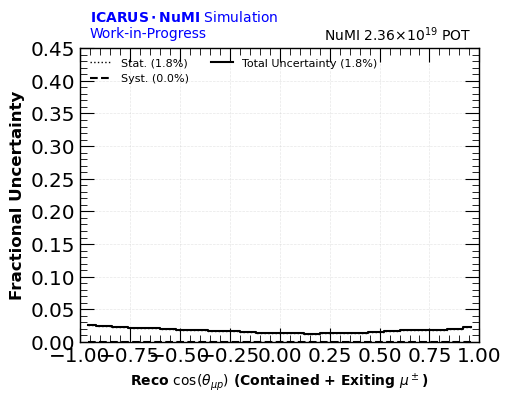

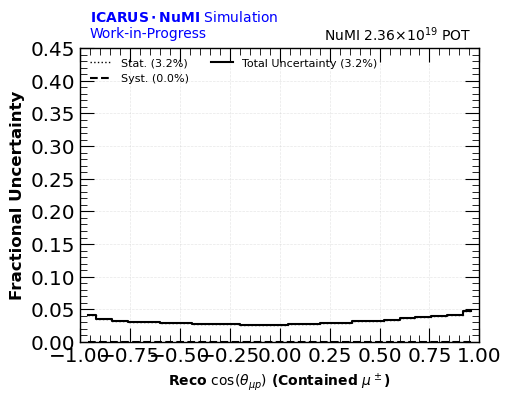

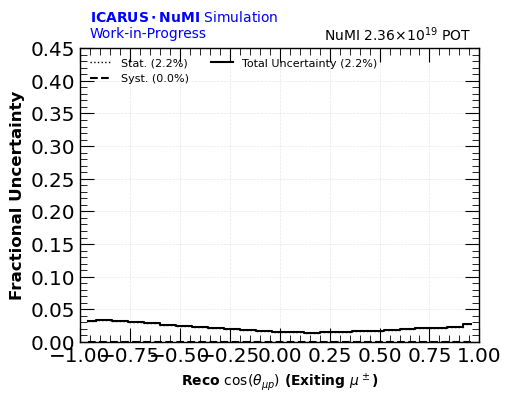

In [6]:
analysis = Analysis(ana_directory + '/opening_angle/opening_angle.toml', data_file)
analysis.run(close_figs=False)

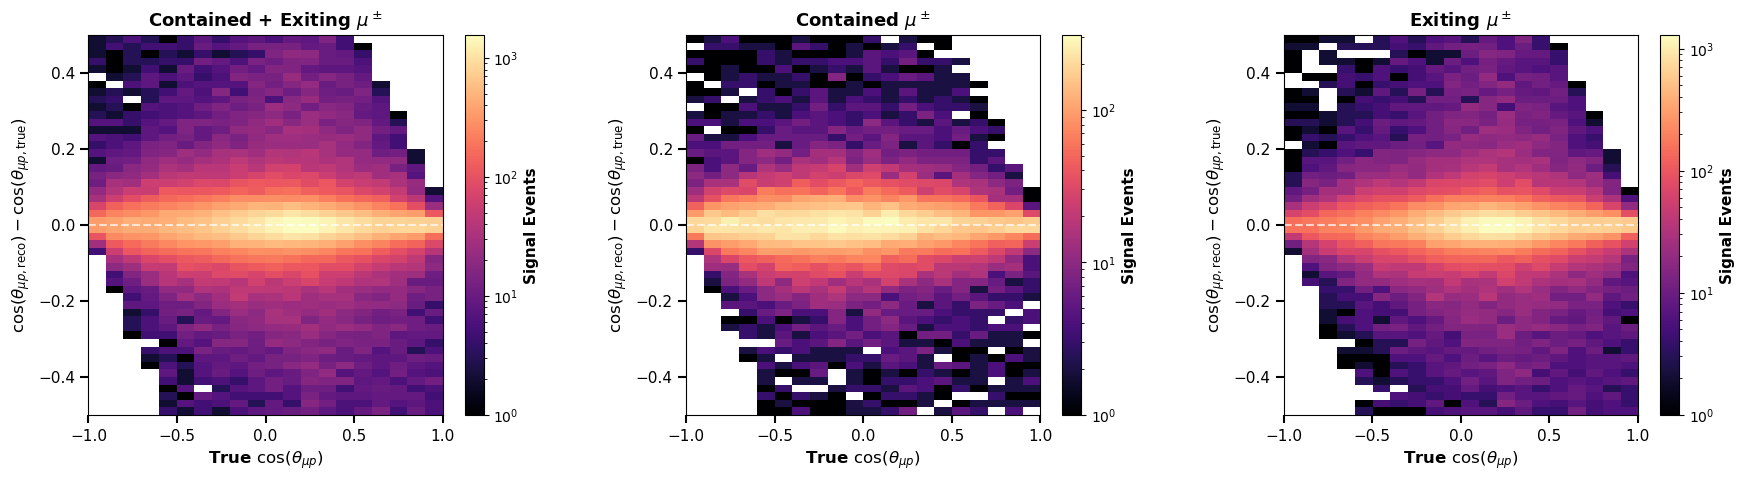

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_cos        = tree['reco_opening_angle_cos'].array(library='np')
    true_cos        = tree['true_opening_angle_cos'].array(library='np')
    true_category   = tree['true_category'].array(library='np')
    muon_contained  = tree['reco_leading_muon_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_cos) &
    np.isfinite(reco_cos) &
    (np.abs(reco_cos) <= 1) &
    (np.abs(true_cos) <= 1)
)

# Compute absolute residual
abs_residual = reco_cos - true_cos

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (muon_contained == 1)
exiting_mask   = signal_mask & valid_mask & (muon_contained == 0)

# Binning
x_bins = np.linspace(-1, 1, 21)
y_bins = np.linspace(-0.5, 0.5, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $\mu^\pm$',
    r'Contained $\mu^\pm$',
    r'Exiting $\mu^\pm$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_cos[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True $\cos(\theta_{\mu p})$', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$\cos(\theta_{\mu p,\mathrm{reco}}) - \cos(\theta_{\mu p,\mathrm{true}})$',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)

plt.savefig('pdf/opening_angle_resolution_vs_true.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Opening angle cross-section uncertainties
analysis = Analysis(ana_directory + '/opening_angle/opening_angle_xSecUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Opening angle cross-section uncertainties expanded
analysis = Analysis(ana_directory + '/opening_angle/opening_angle_xSecUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Opening angle flux uncertainties
analysis = Analysis(ana_directory + '/opening_angle/opening_angle_FluxUncertainty.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Opening angle flux uncertainties expanded
analysis = Analysis(ana_directory + '/opening_angle/opening_angle_FluxUncertainty_Exp.toml', data_file)
analysis.run(close_figs=False)

In [ ]:
# Opening angle detector uncertainties
analysis = Analysis(ana_directory + '/opening_angle/opening_angle_DetectorUncertainty.toml', data_file)
analysis.run(close_figs=False)